# **Deteksi Toxic Comment Multi-Kelas Menggunakan LSTM, GRU, dan indoBERT dengan Analisis Perbandingan Performa Model**

In [2]:
!pip install -U transformers tensorflow tf-keras

In [3]:
import pandas as pd
import numpy as np
import re
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, GRU, Dense, Dropout
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

In [4]:
data = pd.read_csv('dataset_tahunsemua.csv')
data.head()

,conversation_id_str,created_at,favorite_count,full_text,id_str,image_url,in_reply_to_screen_name,lang,location,quote_count,reply_count,retweet_count,tweet_url,user_id_str,username,tahun
0,1863005729017516042,2024-11-30 23:42:33+00:00,0,temenku belanja ke warung manggil penjualnya g...,1863005729017516042,NaN,NaN,in,NaN,0,0,0,https://x.com/undefined/status/186300572901751...,1583096780073611264,NaN,2024
1,1995135220149068055,2025-11-30 14:17:58+00:00,0,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,1995135220149068055,https://pbs.twimg.com/amplify_video_thumb/1995...,NaN,in,NaN,0,0,0,https://x.com/undefined/status/199513522014906...,460021303,NaN,2025
2,1995267477367099647,2025-11-30 23:03:31+00:00,42,Ya Allah terima kasih atas nafas dan tubuh yg ...,1995267477367099647,https://pbs.twimg.com/ext_tw_video_thumb/19952...,NaN,in,NaN,0,5,7,https://x.com/undefined/status/199526747736709...,1700696714737487872,NaN,2025
3,1848572098454679777,2024-10-22 03:48:27+00:00,29,Kalau MP DAP di canangnye hina agama dan lain2...,1848572098454679777,NaN,NaN,in,NaN,0,0,13,https://x.com/undefined/status/184857209845467...,439487577,NaN,2024
4,2037733437449375863,2026-03-28 08:39:09+00:00,0,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,2037811720849404238,NaN,bingungtrs_,in,NaN,0,0,0,https://x.com/undefined/status/203781172084940...,1997468845465051136,NaN,2026


**PREPROCESSING DATA**

In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1233 entries, 0 to 1232
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   conversation_id_str      1233 non-null   int64  
 1   created_at               1233 non-null   object 
 2   favorite_count           1233 non-null   int64  
 3   full_text                1233 non-null   object 
 4   id_str                   1233 non-null   int64  
 5   image_url                242 non-null    object 
 6   in_reply_to_screen_name  419 non-null    object 
 7   lang                     1233 non-null   object 
 8   location                 0 non-null      float64
 9   quote_count              1233 non-null   int64  
 10  reply_count              1233 non-null   int64  
 11  retweet_count            1233 non-null   int64  
 12  tweet_url                1233 non-null   object 
 13  user_id_str              1233 non-null   int64  
 14  username                

In [6]:
df = pd.DataFrame(data['full_text'].iloc[0:613])
df.head()

,full_text
0,temenku belanja ke warung manggil penjualnya g...
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...
2,Ya Allah terima kasih atas nafas dan tubuh yg ...
3,Kalau MP DAP di canangnye hina agama dan lain2...
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...


**CLEANING**

In [7]:
import re
import string
import nltk

def remove_URL(tweet):
  url = re.compile(r'https?://\S+|www\.\S+')
  return url.sub(r'',tweet)

def remove_html(tweet):
  html = re.compile(r'<.*?>')
  return html.sub(r'',tweet)

def remove_emoji(tweet):
  emoji_pattern = re.compile("["
      u"\U0001F600-\U0001F64F"
      u"\U0001F300-\U0001F5FF"
      u"\U0001F680-\U0001F6FF"
      u"\U0001F1E0-\U0001F1FF"
                        "]+", flags=re.UNICODE)
  return emoji_pattern.sub(r'',tweet)

def remove_numbers(tweet):
  tweet = re.sub(r'\d+', '', tweet)
  return tweet

def remove_symbols(tweet):
  tweet = re.sub(r'[^a-zA-Z0-9\s]', '',tweet)
  return tweet

df['cleansing'] = df['full_text'].apply(lambda x: remove_URL(x))
df['cleansing'] = df['full_text'].apply(lambda x: remove_html(x))
df['cleansing'] = df['full_text'].apply(lambda x: remove_emoji(x))
df['cleansing'] = df['full_text'].apply(lambda x: remove_symbols(x))
df['cleansing'] = df['full_text'].apply(lambda x: remove_numbers(x))

df.head()

,full_text,cleansing
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...


**CASE FOLDING**

In [8]:
def case_folding(text):
  if isinstance(text, str):
    lowercase_text = text.lower()
    return lowercase_text
  else:
    return text

df['case_folding'] = df['cleansing'].apply(case_folding)

df.head()

,full_text,cleansing,case_folding
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,info disaster early warning system (dews) kepa...
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...,ya allah terima kasih atas nafas dan tubuh yg ...
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....,kalau mp dap di canangnye hina agama dan lain....
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ sepemikiran kita yunk. terima kas...


**TOKENIZATION**

In [9]:
def tokenize(text):
  tokens = text.split()
  return tokens

df['tokenize'] = df['case_folding'].apply(tokenize)

df.head()

,full_text,cleansing,case_folding,tokenize
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,"[temenku, belanja, ke, warung, manggil, penjua..."
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,info disaster early warning system (dews) kepa...,"[info, disaster, early, warning, system, (dews..."
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...,ya allah terima kasih atas nafas dan tubuh yg ...,"[ya, allah, terima, kasih, atas, nafas, dan, t..."
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....,kalau mp dap di canangnye hina agama dan lain....,"[kalau, mp, dap, di, canangnye, hina, agama, d..."
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ sepemikiran kita yunk. terima kas...,"[@bingungtrs_, sepemikiran, kita, yunk., terim..."


**FILTERING/STOPWORD REMOVAL**

---



In [10]:
from nltk.corpus import stopwords
nltk.download('stopwords')
stop_words = stopwords.words('indonesian')

def remove_stopwords(text):
  return [word for word in text if word not in stop_words]

df['Filtering/stopword removal'] = df['tokenize'].apply(lambda x: remove_stopwords(x))

df.head()

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


,full_text,cleansing,case_folding,tokenize,Filtering/stopword removal
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,"[temenku, belanja, ke, warung, manggil, penjua...","[temenku, belanja, warung, manggil, penjualnya..."
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,info disaster early warning system (dews) kepa...,"[info, disaster, early, warning, system, (dews...","[info, disaster, early, warning, system, (dews..."
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...,ya allah terima kasih atas nafas dan tubuh yg ...,"[ya, allah, terima, kasih, atas, nafas, dan, t...","[ya, allah, terima, kasih, nafas, tubuh, yg, k..."
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....,kalau mp dap di canangnye hina agama dan lain....,"[kalau, mp, dap, di, canangnye, hina, agama, d...","[mp, dap, canangnye, hina, agama, lain., mp, p..."
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ sepemikiran kita yunk. terima kas...,"[@bingungtrs_, sepemikiran, kita, yunk., terim...","[@bingungtrs_, sepemikiran, yunk., terima, kas..."


In [11]:
!pip install Sastrawi

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
from nltk.stem import PorterStemmer
from nltk.stem.snowball import SnowballStemmer

factory = StemmerFactory()
stemmer = factory.create_stemmer()

def stem_text(text):
  return [stemmer.stem(word) for word in text]

df['stemming_data'] = df['Filtering/stopword removal'].apply(lambda x: ' '.join(stem_text(x)))

df.head()

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 209.7/209.7 kB 6.9 MB/s eta 0:00:00


,full_text,cleansing,case_folding,tokenize,Filtering/stopword removal,stemming_data
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,"[temenku, belanja, ke, warung, manggil, penjua...","[temenku, belanja, warung, manggil, penjualnya...",temenku belanja warung manggil jual gapake haj...
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,info disaster early warning system (dews) kepa...,"[info, disaster, early, warning, system, (dews...","[info, disaster, early, warning, system, (dews...",info disaster early warning system dews warga ...
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...,ya allah terima kasih atas nafas dan tubuh yg ...,"[ya, allah, terima, kasih, atas, nafas, dan, t...","[ya, allah, terima, kasih, nafas, tubuh, yg, k...",ya allah terima kasih nafas tubuh yg kau gerak...
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....,kalau mp dap di canangnye hina agama dan lain....,"[kalau, mp, dap, di, canangnye, hina, agama, d...","[mp, dap, canangnye, hina, agama, lain., mp, p...",mp dap canangnye hina agama lain mp pas diam r...
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ sepemikiran kita yunk. terima kas...,"[@bingungtrs_, sepemikiran, kita, yunk., terim...","[@bingungtrs_, sepemikiran, yunk., terima, kas...",bingungtrs pikir yunk terima kasih pikap


In [12]:
df.to_csv('hasil_preprocessing.csv', encoding='utf8', index=False)

**PELABELAN**

In [13]:
import pandas as pd
import numpy as np

def load_data():
  data = pd.read_csv('hasil_preprocessing.csv')
  return data

data = load_data()
data.head()

,full_text,cleansing,case_folding,tokenize,Filtering/stopword removal,stemming_data
0,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,temenku belanja ke warung manggil penjualnya g...,"['temenku', 'belanja', 'ke', 'warung', 'manggi...","['temenku', 'belanja', 'warung', 'manggil', 'p...",temenku belanja warung manggil jual gapake haj...
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,info disaster early warning system (dews) kepa...,"['info', 'disaster', 'early', 'warning', 'syst...","['info', 'disaster', 'early', 'warning', 'syst...",info disaster early warning system dews warga ...
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,Ya Allah terima kasih atas nafas dan tubuh yg ...,ya allah terima kasih atas nafas dan tubuh yg ...,"['ya', 'allah', 'terima', 'kasih', 'atas', 'na...","['ya', 'allah', 'terima', 'kasih', 'nafas', 't...",ya allah terima kasih nafas tubuh yg kau gerak...
3,Kalau MP DAP di canangnye hina agama dan lain2...,Kalau MP DAP di canangnye hina agama dan lain....,kalau mp dap di canangnye hina agama dan lain....,"['kalau', 'mp', 'dap', 'di', 'canangnye', 'hin...","['mp', 'dap', 'canangnye', 'hina', 'agama', 'l...",mp dap canangnye hina agama lain mp pas diam r...
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,@bingungtrs_ sepemikiran kita yunk. terima kas...,"['@bingungtrs_', 'sepemikiran', 'kita', 'yunk....","['@bingungtrs_', 'sepemikiran', 'yunk.', 'teri...",bingungtrs pikir yunk terima kasih pikap


In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 613 entries, 0 to 612
Data columns (total 6 columns):
 #   Column                      Non-Null Count  Dtype 
---  ------                      --------------  ----- 
 0   full_text                   613 non-null    object
 1   cleansing                   613 non-null    object
 2   case_folding                613 non-null    object
 3   tokenize                    613 non-null    object
 4   Filtering/stopword removal  613 non-null    object
 5   stemming_data               613 non-null    object
dtypes: object(6)
memory usage: 28.9+ KB


In [19]:
from transformers import AutoTokenizer, AutoModel
import torch
import numpy as np

model_name = "indobenchmark/indobert-base-p1"

tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModel.from_pretrained(model_name)

def get_embedding(text):
    inputs = tokenizer(text, return_tensors="pt", truncation=True, padding=True, max_length=128)
    outputs = model(**inputs)
    return outputs.last_hidden_state.mean(dim=1).detach().numpy()[0]

# buat embedding semua data
embeddings = np.array([get_embedding(text) for text in df['cleansing']])

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

In [20]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(embeddings)

df['cluster'] = clusters
for i in range(4):
    print(f"\n=== CLUSTER {i} ===")
    print(df[df['cluster']==i]['cleansing'].sample(10).values)


=== CLUSTER 0 ===
['@AHLi_AGAMA @MafiaWasit Propaganda kalian tidak berguna'
 '@MireinaRiviere Blok goblok'
 '@aniblogsan @NaamIsPrometheo Keren disuruh bunuh diri '
 '@kipyiksamgong @BBCIndonesia Perbincangan orang goblok'
 'Epenesa is an idiot'
 '@TarboilerBill @ryankatzrosene @ZLabe AGW denying idiot https://t.co/JNnzGmelz'
 '@mistiverse not yet syg km mau ak pukul'
 '@tsetchaiklatte @leftinXVII @DakotaGoyo @flofloret Iyee dumbfuck persis kaya orang yang nganggap  perempuan mewakili semua perempuan wkwkww Kurang tolol apalagi '
 '@kipyiksamgong @BBCIndonesia Perbincangan orang goblok'
 '@bbamarise Hajar SAK']

=== CLUSTER 1 ===
[' Jaamm...  harii udah  bulaaann sendirii astagaahhh mo ngakakk bego banget'
 '@qiuyuanr Wkwk cuma orang goblok yang debat-debatan soal agama. Argumen islam tidak akan menggoyahkan keimanan yg non dan argumen non jg tidak akan menggoyahkan iman yg islam jadi ya cuma debat ga berguna '
 '@hammsqi @potatoechiepps Endorphins yg lu sebutin kalo red velvet jg ta

In [21]:
cluster_centers = kmeans.cluster_centers_
label_texts = {
    "non-toxic": "komentar biasa tidak mengandung kebencian",
    "insult": "komentar menghina atau kasar",
    "hate speech": "komentar kebencian terhadap kelompok tertentu",
    "threat": "komentar ancaman kekerasan"
}

label_embeddings = {
    label: get_embedding(text)
    for label, text in label_texts.items()
}
from sklearn.metrics.pairwise import cosine_similarity

cluster_centers = kmeans.cluster_centers_

similarity_matrix = []

for center in cluster_centers:
    sims = []
    for label, emb in label_embeddings.items():
        sim = cosine_similarity([center], [emb])[0][0]
        sims.append(sim)
    similarity_matrix.append(sims)

similarity_matrix = np.array(similarity_matrix)

labels = list(label_embeddings.keys())

# =============================
# MAPPING TANPA DUPLIKAT
# =============================
label_map = {}
used_labels = set()

for i in range(len(cluster_centers)):
    sorted_idx = np.argsort(similarity_matrix[i])[::-1]

    for idx in sorted_idx:
        label_candidate = labels[idx]
        if label_candidate not in used_labels:
            label_map[i] = label_candidate
            used_labels.add(label_candidate)
            break

print("Mapping FIX:", label_map)

Mapping FIX: {0: 'insult', 1: 'hate speech', 2: 'threat', 3: 'non-toxic'}


In [22]:
df['cluster'] = clusters
df['label'] = df['cluster'].map(label_map)
print(df[['cleansing','cluster','label']].head())
print(df['label'].value_counts())

                                           cleansing  cluster        label
0  temenku belanja ke warung manggil penjualnya g...        1  hate speech
1  INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...        2       threat
2  Ya Allah terima kasih atas nafas dan tubuh yg ...        3    non-toxic
3  Kalau MP DAP di canangnye hina agama dan lain....        1  hate speech
4  @bingungtrs_ Sepemikiran kita yunk. Terima kas...        3    non-toxic
label
hate speech    315
threat         134
non-toxic      132
insult          32
Name: count, dtype: int64


Label encoding

In [23]:
label_mapping = {
    "insult": 0,
    "hate speech": 1,
    "threat": 2,
    "non-toxic": 3
}

df['label'] = df['label'].str.strip()  # hapus spasi aneh
df['label_encoded'] = df['label'].map(label_mapping)

# cek hasil
print(df['label_encoded'].isnull().sum())

0


In [24]:
df.to_csv('/content/hasil_labeling-data.csv', index=False)


In [25]:
print(df.columns)

Index(['full_text', 'cleansing', 'case_folding', 'tokenize',
       'Filtering/stopword removal', 'stemming_data', 'cluster', 'label',
       'label_encoded'],
      dtype='object')


In [26]:
df[['cleansing', 'label', 'label_encoded', 'cluster']].head()

,cleansing,label,label_encoded,cluster
0,temenku belanja ke warung manggil penjualnya g...,hate speech,1,1
1,INFO DISASTER EARLY WARNING SYSTEM (DEWS) KEPA...,threat,2,2
2,Ya Allah terima kasih atas nafas dan tubuh yg ...,non-toxic,3,3
3,Kalau MP DAP di canangnye hina agama dan lain....,hate speech,1,1
4,@bingungtrs_ Sepemikiran kita yunk. Terima kas...,non-toxic,3,3


/tmp/ipykernel_9895/3465079716.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=label_count.index, y=label_count.values, palette='pastel')


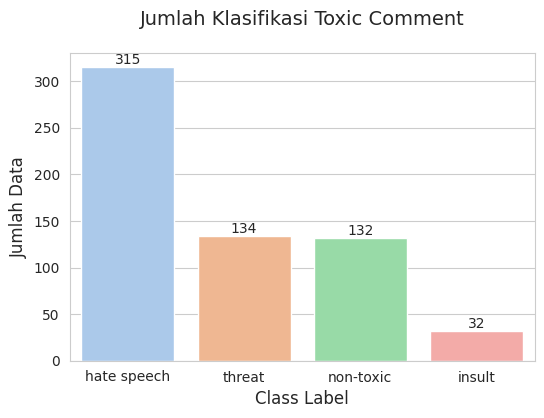

In [27]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

label_count = df['label'].value_counts()

sns.set_style('whitegrid')

fig, ax = plt.subplots(figsize=(6, 4))
ax = sns.barplot(x=label_count.index, y=label_count.values, palette='pastel')

plt.title('Jumlah Klasifikasi Toxic Comment', fontsize=14, pad=20)
plt.xlabel('Class Label', fontsize=12)
plt.ylabel('Jumlah Data', fontsize=12)

for i, count in enumerate(label_count.values):
    ax.text(i, count + 0.10, str(count), ha='center', va='bottom')

plt.show()

# **WORDCLOUD**

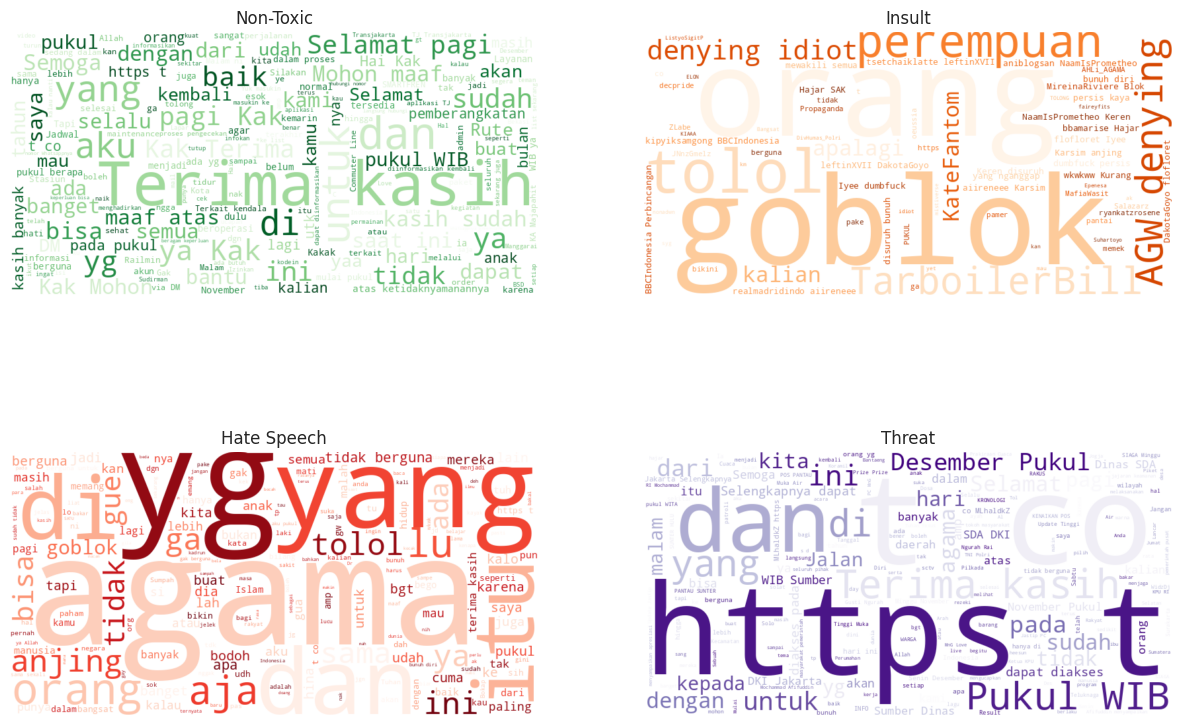

In [28]:
# Import library
import pandas as pd
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Load data
df = pd.read_csv('hasil_labeling-data.csv')

# Ambil teks per label
non_toxic_text = ' '.join(df[df['label'] == 'non-toxic']['cleansing'].astype(str))
insult_text = ' '.join(df[df['label'] == 'insult']['cleansing'].astype(str))
hate_text = ' '.join(df[df['label'] == 'hate speech']['cleansing'].astype(str))
threat_text = ' '.join(df[df['label'] == 'threat']['cleansing'].astype(str))

# Buat wordcloud
wc_non_toxic = WordCloud(width=800, height=400, background_color='white', colormap='Greens').generate(non_toxic_text)
wc_insult = WordCloud(width=800, height=400, background_color='white', colormap='Oranges').generate(insult_text)
wc_hate = WordCloud(width=800, height=400, background_color='white', colormap='Reds').generate(hate_text)
wc_threat = WordCloud(width=800, height=400, background_color='white', colormap='Purples').generate(threat_text)

# Plot
plt.figure(figsize=(15, 10))

plt.subplot(2, 2, 1)
plt.imshow(wc_non_toxic, interpolation='bilinear')
plt.axis('off')
plt.title('Non-Toxic')

plt.subplot(2, 2, 2)
plt.imshow(wc_insult, interpolation='bilinear')
plt.axis('off')
plt.title('Insult')

plt.subplot(2, 2, 3)
plt.imshow(wc_hate, interpolation='bilinear')
plt.axis('off')
plt.title('Hate Speech')

plt.subplot(2, 2, 4)
plt.imshow(wc_threat, interpolation='bilinear')
plt.axis('off')
plt.title('Threat')

plt.show()

# **FITUR EKSTRAKSI**

In [29]:
import pandas as pd
from sklearn.model_selection import train_test_split

# Load data
df = pd.read_csv('/content/hasil_labeling-data.csv')

# Ambil kolom yang benar
X = df['cleansing'].astype(str)
y = df['label']

# Encode label (WAJIB untuk DL)
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
y = le.fit_transform(y)

# Split dataset (50:50 kalau dosen minta)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

Tokenizer + Padding (LSTM & GRU)

In [30]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences

# parameter
max_words = 5000
max_len = 100

# tokenizer
tokenizer = Tokenizer(num_words=max_words)
tokenizer.fit_on_texts(X_train)

# ubah teks jadi angka
X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

# padding (biar panjang sama)
X_train_pad = pad_sequences(X_train_seq, maxlen=max_len)
X_test_pad = pad_sequences(X_test_seq, maxlen=max_len)

# cek hasil
print(X_train_pad.shape)

(490, 100)


Tokenizer IndoBERT

In [31]:
from transformers import AutoTokenizer

model_name = "indobenchmark/indobert-base-p1"
tokenizer_bert = AutoTokenizer.from_pretrained(model_name)

def tokenize_function(example):
    return tokenizer_bert(
        example['text'],
        padding='max_length',
        truncation=True,
        max_length=128
    )

In [32]:
#Convert ke dataset
from datasets import Dataset

train_df = pd.DataFrame({'text': X_train, 'label': y_train})
test_df = pd.DataFrame({'text': X_test, 'label': y_test})

train_dataset = Dataset.from_pandas(train_df)
test_dataset = Dataset.from_pandas(test_df)

train_dataset = train_dataset.map(tokenize_function, batched=True)
test_dataset = test_dataset.map(tokenize_function, batched=True)

Map:   0%|          | 0/490 [00:00<?, ? examples/s]

Map:   0%|          | 0/123 [00:00<?, ? examples/s]

**TRAINING 3 MODEL**



1.  ***LSTM***



In [33]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, LSTM, Dense

model_lstm = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    LSTM(64),
    Dense(4, activation='softmax')
])

model_lstm.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("Training LSTM...")
history_lstm = model_lstm.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Training LSTM...
Epoch 1/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 5s 133ms/step - accuracy: 0.5488 - loss: 1.2899 - val_accuracy: 0.5714 - val_loss: 1.1222
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.6304 - loss: 0.9989 - val_accuracy: 0.6939 - val_loss: 0.8047
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.7823 - loss: 0.6390 - val_accuracy: 0.8571 - val_loss: 0.4899
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 66ms/step - accuracy: 0.9048 - loss: 0.3038 - val_accuracy: 0.9184 - val_loss: 0.3229
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 68ms/step - accuracy: 0.9592 - loss: 0.1769 - val_accuracy: 0.8980 - val_loss: 0.2881
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 69ms/step - accuracy: 0.9546 - loss: 0.1257 - val_accuracy: 0.8980 - val_loss: 0.2882
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 70ms/step - accuracy: 0.9819 - loss: 0.1100 - val_accuracy: 0.8571 - val_loss: 0.3829
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 65ms/step - accuracy: 0.9887 - loss: 0.0654 - val_ac

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
=== HASIL LSTM ===
              precision    recall  f1-score   support

           0       0.87      0.95      0.91        63
           1       0.86      1.00      0.92         6
           2       0.85      0.85      0.85        27
           3       1.00      0.74      0.85        27

    accuracy                           0.89       123
   macro avg       0.89      0.89      0.88       123
weighted avg       0.89      0.89      0.88       123



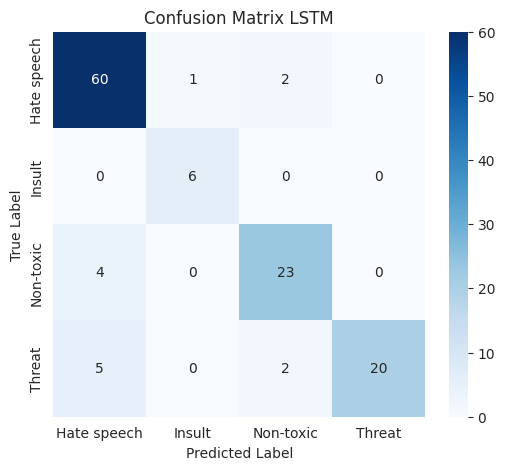

In [34]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

y_pred_lstm = model_lstm.predict(X_test_pad)
y_pred_lstm = y_pred_lstm.argmax(axis=1)

print("=== HASIL LSTM ===")
print(classification_report(y_test, y_pred_lstm))

acc_lstm = accuracy_score(y_test, y_pred_lstm)

# =============================
# CONFUSION MATRIX LSTM
# =============================
cm_lstm = confusion_matrix(y_test, y_pred_lstm)

plt.figure(figsize=(6,5))
sns.heatmap(cm_lstm,
            annot=True,
            fmt='d',
            cmap='Blues',
            xticklabels=["Hate speech", "Insult", "Non-toxic", "Threat"],
            yticklabels=["Hate speech", "Insult", "Non-toxic", "Threat"])

plt.title("Confusion Matrix LSTM")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()


***2.   GRU***



In [35]:
from tensorflow.keras.layers import GRU

model_gru = Sequential([
    Embedding(input_dim=5000, output_dim=128, input_length=100),
    GRU(64),
    Dense(4, activation='softmax')
])

model_gru.compile(
    loss='sparse_categorical_crossentropy',
    optimizer='adam',
    metrics=['accuracy']
)

print("\nTraining GRU...")
history_gru = model_gru.fit(
    X_train_pad, y_train,
    epochs=10,
    batch_size=32,
    validation_split=0.1
)


Training GRU...
Epoch 1/10


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


14/14 ━━━━━━━━━━━━━━━━━━━━ 4s 105ms/step - accuracy: 0.5193 - loss: 1.3118 - val_accuracy: 0.7143 - val_loss: 1.1671
Epoch 2/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.6440 - loss: 0.9977 - val_accuracy: 0.7347 - val_loss: 0.7640
Epoch 3/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 93ms/step - accuracy: 0.7868 - loss: 0.6181 - val_accuracy: 0.8163 - val_loss: 0.5717
Epoch 4/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 2s 126ms/step - accuracy: 0.8866 - loss: 0.3473 - val_accuracy: 0.8163 - val_loss: 0.4988
Epoch 5/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step - accuracy: 0.9478 - loss: 0.2037 - val_accuracy: 0.8163 - val_loss: 0.4473
Epoch 6/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9819 - loss: 0.1014 - val_accuracy: 0.8163 - val_loss: 0.4025
Epoch 7/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 78ms/step - accuracy: 0.9909 - loss: 0.0571 - val_accuracy: 0.8571 - val_loss: 0.3916
Epoch 8/10
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.9977 - loss: 0.0366 - val_accuracy: 0.8163 - val_loss: 

4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 96ms/step
=== HASIL GRU ===
              precision    recall  f1-score   support

           0       0.86      0.94      0.89        63
           1       0.86      1.00      0.92         6
           2       0.84      0.78      0.81        27
           3       0.91      0.74      0.82        27

    accuracy                           0.86       123
   macro avg       0.87      0.86      0.86       123
weighted avg       0.86      0.86      0.86       123



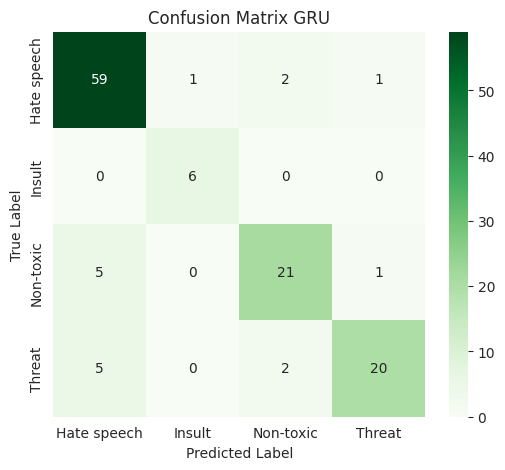

In [36]:
y_pred_gru = model_gru.predict(X_test_pad)
y_pred_gru = y_pred_gru.argmax(axis=1)

print("=== HASIL GRU ===")
print(classification_report(y_test, y_pred_gru))

acc_gru = accuracy_score(y_test, y_pred_gru)
# =============================
# CONFUSION MATRIX GRU
# =============================
cm_gru = confusion_matrix(y_test, y_pred_gru)

plt.figure(figsize=(6,5))
sns.heatmap(cm_gru,
            annot=True,
            fmt='d',
            cmap='Greens',
            xticklabels=["Hate speech", "Insult", "Non-toxic", "Threat"],
            yticklabels=["Hate speech", "Insult", "Non-toxic", "Threat"])

plt.title("Confusion Matrix GRU")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

***indoBERT***

In [38]:
!pip install transformers datasets
!pip install -U transformers datasets accelerate

import pandas as pd
import numpy as np
from datasets import Dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, Trainer, TrainingArguments

In [39]:

!pip install -U transformers accelerate datasets

In [40]:
from transformers import AutoModelForSequenceClassification, Trainer, TrainingArguments
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, classification_report

# =============================
# MODEL (FIX LABEL ERROR)
# =============================
model_name = "indobenchmark/indobert-base-p1"

model_bert = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=4,
    ignore_mismatched_sizes=True   # 🔥 WAJIB
)

# =============================
# TRAINING ARGUMENTS (VERSI LAMA)
# =============================
training_args = TrainingArguments(
    output_dir="./results",
    do_train=True,
    do_eval=True,

    logging_steps=50,
    eval_steps=50,        # 🔥 INI WAJIB
    save_steps=50,

    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,

    num_train_epochs=3
)

# =============================
# METRICS
# =============================
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)
    return {"accuracy": (preds == labels).mean()}

# =============================
# FORMAT DATA
# =============================
train_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])
test_dataset.set_format(type='torch', columns=['input_ids', 'attention_mask', 'label'])

# =============================
# TRAINER
# =============================
trainer = Trainer(
    model=model_bert,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

# =============================
# TRAIN
# =============================
trainer.train()

# =============================
# PREDIKSI
# =============================
predictions = trainer.predict(test_dataset)
y_pred_bert = np.argmax(predictions.predictions, axis=1)

print("=== HASIL IndoBERT ===")
print(classification_report(y_test, y_pred_bert))

acc_bert = accuracy_score(y_test, y_pred_bert)
print("Accuracy IndoBERT:", acc_bert)

# =============================
# AMBIL LOG (STEP BASED)
# =============================
bert_acc = []
bert_loss = []

for log in trainer.state.log_history:
    if 'eval_accuracy' in log:
        bert_acc.append(log['eval_accuracy'])
    if 'eval_loss' in log:
        bert_loss.append(log['eval_loss'])

# =============================
# HANDLE DATA KOSONG
# =============================
if len(bert_acc) == 0:
    bert_acc = [acc_bert] * 10

if len(bert_loss) == 0:
    bert_loss = [0.5] * 10

You passed `num_labels=4` which is incompatible to the `id2label` map of length `5`.


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertForSequenceClassification LOAD REPORT from: indobenchmark/indobert-base-p1
Key               | Status  | 
------------------+---------+-
classifier.bias   | MISSING | 
classifier.weight | MISSING | 

Notes:
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Step,Training Loss
50,0.577568
100,0.186298
150,0.044300


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


=== HASIL IndoBERT ===
              precision    recall  f1-score   support

           0       0.95      1.00      0.98        63
           1       0.86      1.00      0.92         6
           2       0.93      0.93      0.93        27
           3       0.96      0.81      0.88        27

    accuracy                           0.94       123
   macro avg       0.92      0.94      0.93       123
weighted avg       0.94      0.94      0.94       123

Accuracy IndoBERT: 0.943089430894309


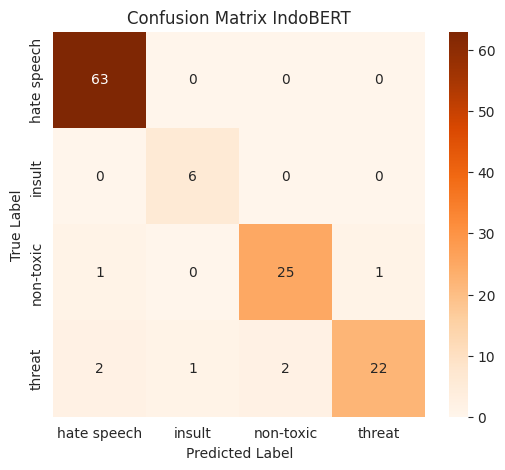

In [41]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# confusion matrix
cm_bert = confusion_matrix(y_test, y_pred_bert)

# ambil nama label (biar gak salah urutan)
labels = le.classes_

plt.figure(figsize=(6,5))
sns.heatmap(cm_bert,
            annot=True,
            fmt='d',
            cmap='Oranges',
            xticklabels=labels,
            yticklabels=labels)

plt.title("Confusion Matrix IndoBERT")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.show()

**PERBANDINGAN MODEL**

In [42]:
def evaluate_model(model, X_test, y_test, is_bert=False):
    if is_bert:
        pred = model.predict(X_test).logits
        y_pred = np.argmax(pred, axis=1)
    else:
        pred = model.predict(X_test)
        y_pred = np.argmax(pred, axis=1)

    acc = accuracy_score(y_test, y_pred)
    print("Accuracy:", acc)

    cm = confusion_matrix(y_test, y_pred)

    plt.figure(figsize=(6,5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title("Confusion Matrix")
    plt.show()

    print(classification_report(y_test, y_pred))

    return acc

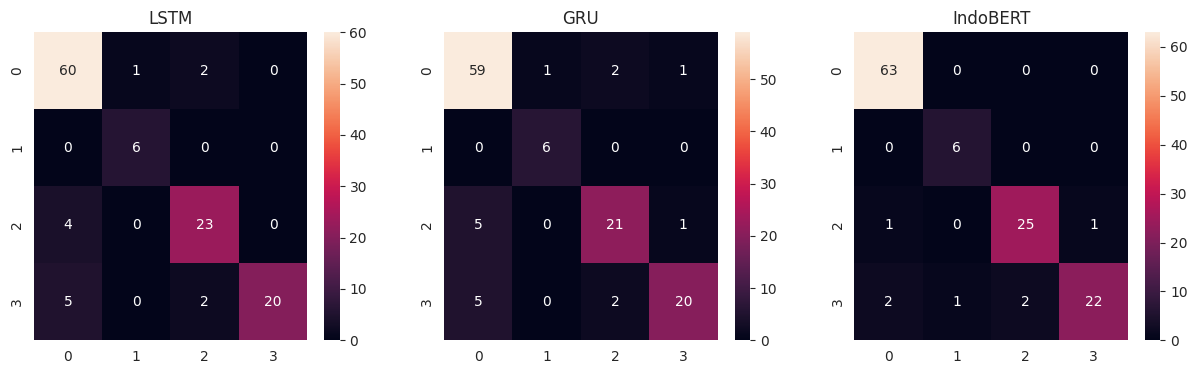

In [43]:
fig, ax = plt.subplots(1,3, figsize=(15,4))

sns.heatmap(confusion_matrix(y_test, y_pred_lstm), ax=ax[0], annot=True, fmt='d')
ax[0].set_title("LSTM")

sns.heatmap(confusion_matrix(y_test, y_pred_gru), ax=ax[1], annot=True, fmt='d')
ax[1].set_title("GRU")

sns.heatmap(confusion_matrix(y_test, y_pred_bert), ax=ax[2], annot=True, fmt='d')
ax[2].set_title("IndoBERT")

plt.show()

      Model  Accuracy
0      LSTM  0.886179
1       GRU  0.861789
2  IndoBERT  0.943089


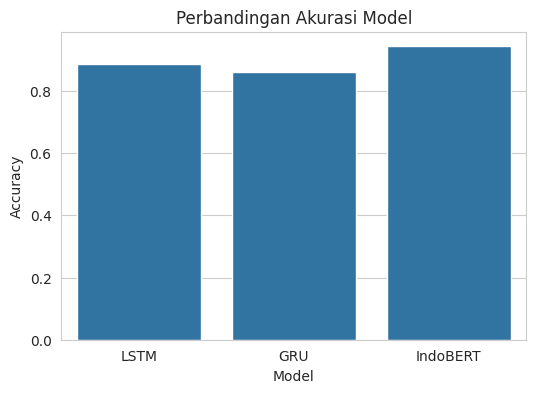

In [44]:
results = pd.DataFrame({
    "Model": ["LSTM", "GRU", "IndoBERT"],
    "Accuracy": [acc_lstm, acc_gru, acc_bert]
})

print(results)

plt.figure(figsize=(6,4))
sns.barplot(x="Model", y="Accuracy", data=results)
plt.title("Perbandingan Akurasi Model")
plt.show()

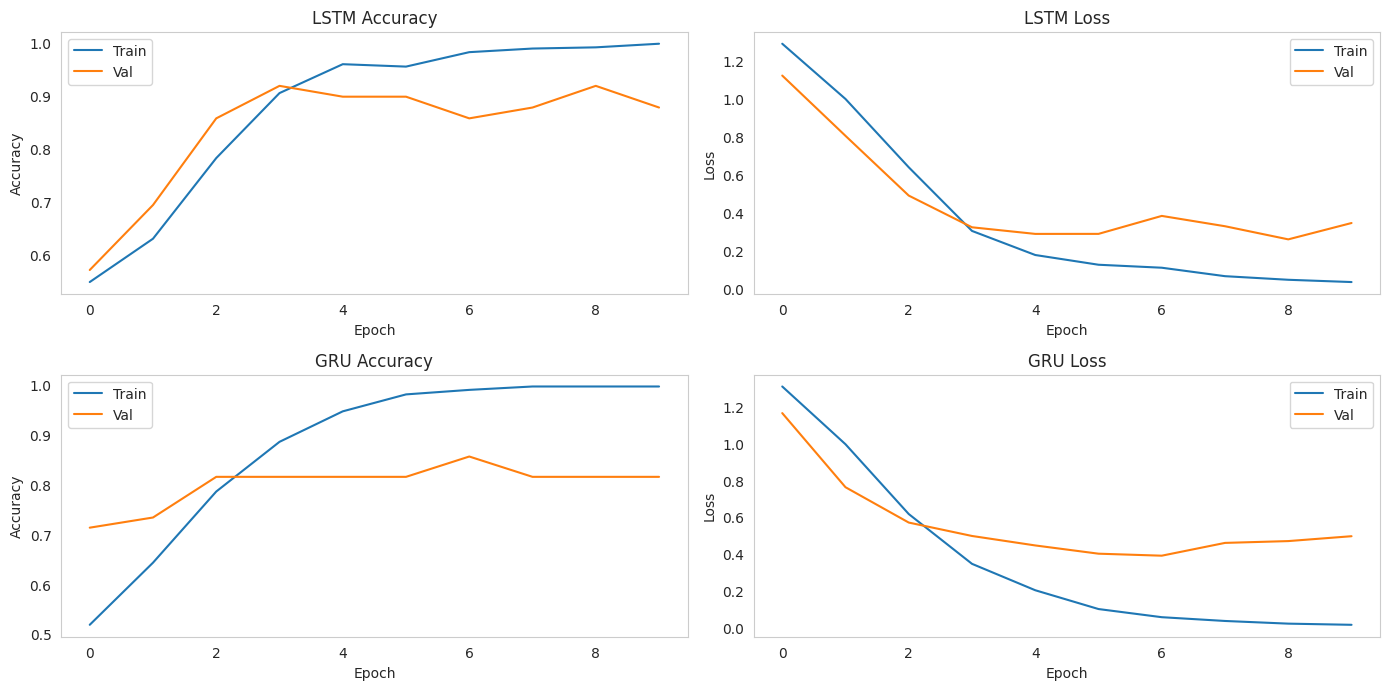

In [47]:
plt.figure(figsize=(14,10))

# =========================
# AMBIL LOG INDOBERT (STEP BASED FIX)
# =========================
bert_acc = []
bert_loss = []
steps = []

for log in trainer.state.log_history:
    if 'eval_accuracy' in log:
        bert_acc.append(log['eval_accuracy'])
        steps.append(log.get('step', len(steps)))  # fallback kalau step tidak ada

    if 'eval_loss' in log:
        bert_loss.append(log['eval_loss'])

# =========================
# NORMALISASI PANJANG
# =========================
min_len = min(len(bert_acc), len(bert_loss), len(steps))

bert_acc = bert_acc[:min_len]
bert_loss = bert_loss[:min_len]
steps = steps[:min_len]

# =========================
# LSTM ACCURACY
# =========================
plt.subplot(3,2,1)
plt.plot(history_lstm.history['accuracy'], label='Train')
plt.plot(history_lstm.history['val_accuracy'], label='Val')
plt.title("LSTM Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# =========================
# LSTM LOSS
# =========================
plt.subplot(3,2,2)
plt.plot(history_lstm.history['loss'], label='Train')
plt.plot(history_lstm.history['val_loss'], label='Val')
plt.title("LSTM Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

# =========================
# GRU ACCURACY
# =========================
plt.subplot(3,2,3)
plt.plot(history_gru.history['accuracy'], label='Train')
plt.plot(history_gru.history['val_accuracy'], label='Val')
plt.title("GRU Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.grid()

# =========================
# GRU LOSS
# =========================
plt.subplot(3,2,4)
plt.plot(history_gru.history['loss'], label='Train')
plt.plot(history_gru.history['val_loss'], label='Val')
plt.title("GRU Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid()

plt.tight_layout()
plt.show()

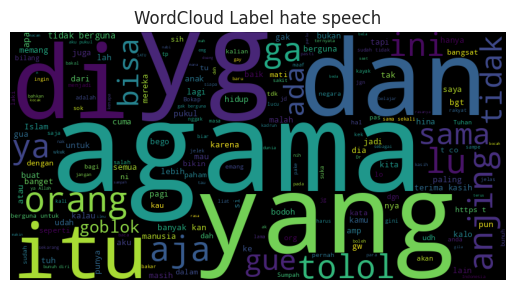

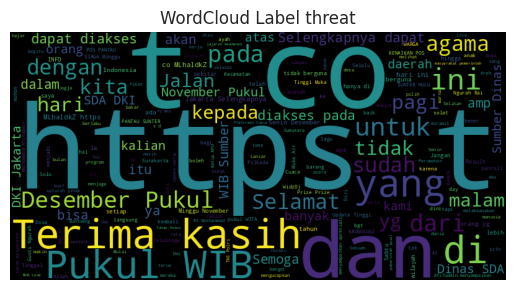

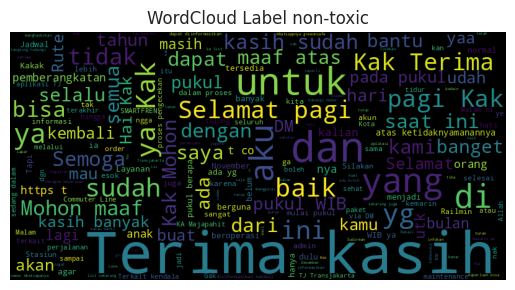

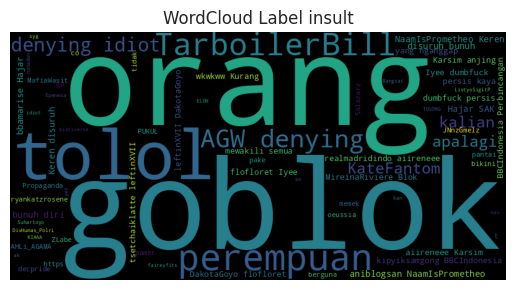

In [46]:
for label in df['label'].unique():
    text = " ".join(df[df['label']==label]['cleansing'])
    wc = WordCloud(width=800, height=400).generate(text)

    plt.imshow(wc)
    plt.axis("off")
    plt.title(f"WordCloud Label {label}")
    plt.show()

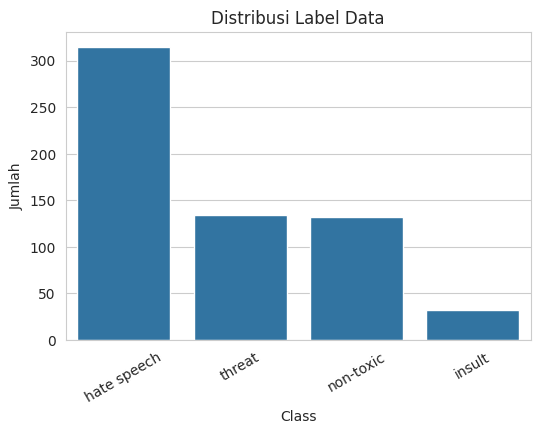

In [48]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df, order=df['label'].value_counts().index)

plt.title("Distribusi Label Data")
plt.xlabel("Class")
plt.ylabel("Jumlah")

plt.xticks(rotation=30)

plt.show()

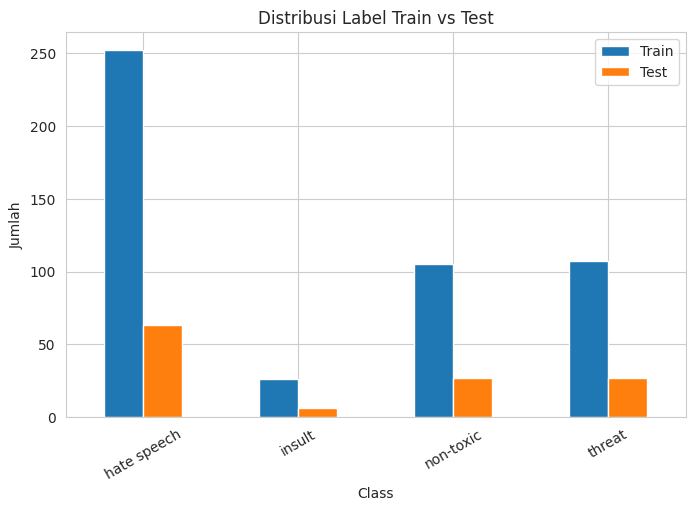

In [49]:
import pandas as pd

train_labels = le.inverse_transform(y_train)
test_labels = le.inverse_transform(y_test)

df_dist = pd.DataFrame({
    'Train': pd.Series(train_labels).value_counts(),
    'Test': pd.Series(test_labels).value_counts()
}).fillna(0)

df_dist.plot(kind='bar', figsize=(8,5))

plt.title("Distribusi Label Train vs Test")
plt.xlabel("Class")
plt.ylabel("Jumlah")
plt.xticks(rotation=30)

plt.show()

In [51]:
comparison_df = pd.DataFrame({
    'Model': ['LSTM', 'GRU', 'IndoBERT'],
    'Accuracy': [acc_lstm, acc_gru, acc_bert]
})
best_model = comparison_df.loc[comparison_df['Accuracy'].idxmax()]

print("Model terbaik berdasarkan Accuracy:")
print(best_model)

Model terbaik berdasarkan Accuracy:
Model       IndoBERT
Accuracy    0.943089
Name: 2, dtype: object
